In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import cv2
import os
import sys
from src.Mem_Model import *
from src.Template_matching import *
# from src.temp_match import *
import json
from src.allf import *
from mpl_toolkits.axes_grid1 import make_axes_locatable

df = pd.read_csv("Data3.csv", header=None)

df.columns = ["Voltage", "Resistance", "Current", "Power"]

# Build nested dictionary safely
data_struct = {
    v: {
        r: float(df.loc[(df["Voltage"] == v) & (df["Resistance"] == r), "Current"].iloc[0])
        for r in df.loc[df["Voltage"] == v, "Resistance"].unique()
    }
    for v in df["Voltage"].unique()
}

R_list = np.unique(df.iloc[:,1].values)

with open('config.json', 'r') as file:
    # Load the JSON data
    data = json.load(file)

mem_model_fitter = Mem_Model("Data3.csv", data["V_column"], data["R_column"], data["I_column"], data["P_column"])

mem_model_fitter.model_creation(clip_ = data["clip_"], R_list = R_list)

In [27]:
# pd.read_csv(data['device_file'], header=None)

# pd.read_csv("Data3.csv", header=None)

# df = pd.read_csv(data['device_file'], header=None)

# RR_list = [5000, 9000, 13000, 17000, 20000]

# df2 = df[df[1].isin(RR_list)]

# Replace_Start = RR_list[0]

# for RR in RR_list:
#     df2[1][df2[1]==RR]=Replace_Start
#     Replace_Start+=1000

# df2.to_csv("Data4.csv", index=False, header=False)

C:\Users\somas\AppData\Local\Temp\ipykernel_22600\1643225679.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[1][df2[1]==RR]=Replace_Start
C:\Users\somas\AppData\Local\Temp\ipykernel_22600\1643225679.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[1][df2[1]==RR]=Replace_Start
C:\Users\somas\AppData\Local\Temp\ipykernel_22600\1643225679.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[1][df2[1]==RR]=Replace_Star

In [15]:
tm2 = Template_matching(mem_model_fitter.model, img_direc = "PeanutBottle1/", temp_img = "template/template2.jpg")

tm2.method = "Approximate"

tm2.template_matching(NL=[0])

# tm3 = Template_matching(mem_model_fitter.model, img_direc = "PeanutBottle1/", temp_img = "template/template2.jpg")

# tm3.method = "Exact"

# tm3.template_matching(NL=[0])

In [30]:
# temp_data = tm2.Data_template.reshape(64, 128)
# y = temp_data - np.mean(temp_data)
# sign_map = np.where(y >= 0, 1, -1).reshape(64, 128)
# temp_R = tm2.R.reshape(64, 128).astype(float)

# np.unique(temp_R)

array([5., 6., 7., 8.])

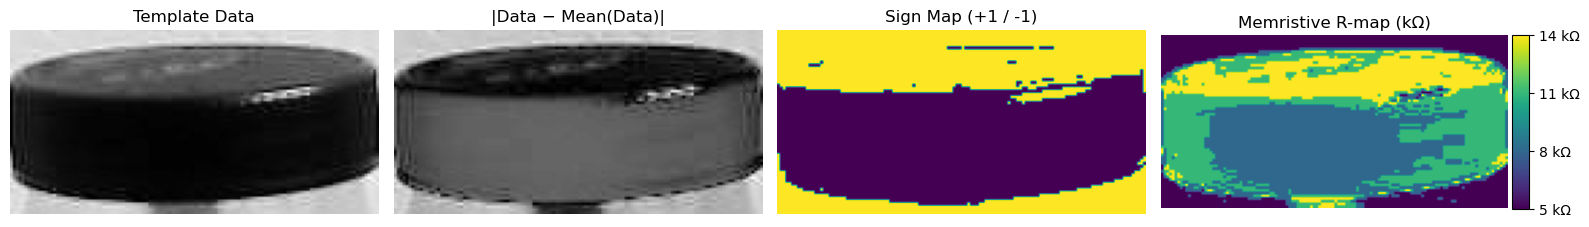

In [16]:
# =============================
# Data Preparation
# =============================
temp_data = tm2.Data_template.reshape(64, 128)
y = temp_data - np.mean(temp_data)
sign_map = np.where(y >= 0, 1, -1).reshape(64, 128)
temp_R = tm2.R.reshape(64, 128).astype(float)

# Define tick positions and labels for colorbar
# RR_list = [5, 9, 13, 17]  # in kilo-ohms
RR_list = [5, 8, 11, 14]  # in kilo-ohms
R_labels = [f"{val} kΩ" for val in RR_list]

# =============================
# Plot Setup
# =============================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# (1) Original Template
im0 = axes[0].imshow(temp_data, cmap="gray")
axes[0].set_title("Template Data")
axes[0].axis("off")

# (2) Absolute Difference Map
im1 = axes[1].imshow(np.abs(y), cmap="gray")
axes[1].set_title("|Data − Mean(Data)|")
axes[1].axis("off")

# (3) Sign Map
im2 = axes[2].imshow(sign_map, cmap="viridis", vmin=-1, vmax=1)
axes[2].set_title("Sign Map (+1 / -1)")
axes[2].axis("off")

# (4) Resistance Map with Colorbar
im3 = axes[3].imshow(temp_R, cmap="viridis")
axes[3].set_title("Memristive R-map (kΩ)")
axes[3].axis("off")

divider = make_axes_locatable(axes[3])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im3, cax=cax)
cbar.set_ticks(np.linspace(np.min(temp_R), np.max(temp_R), len(RR_list)))
cbar.set_ticklabels(R_labels)

# Final layout
plt.tight_layout()
plt.show()

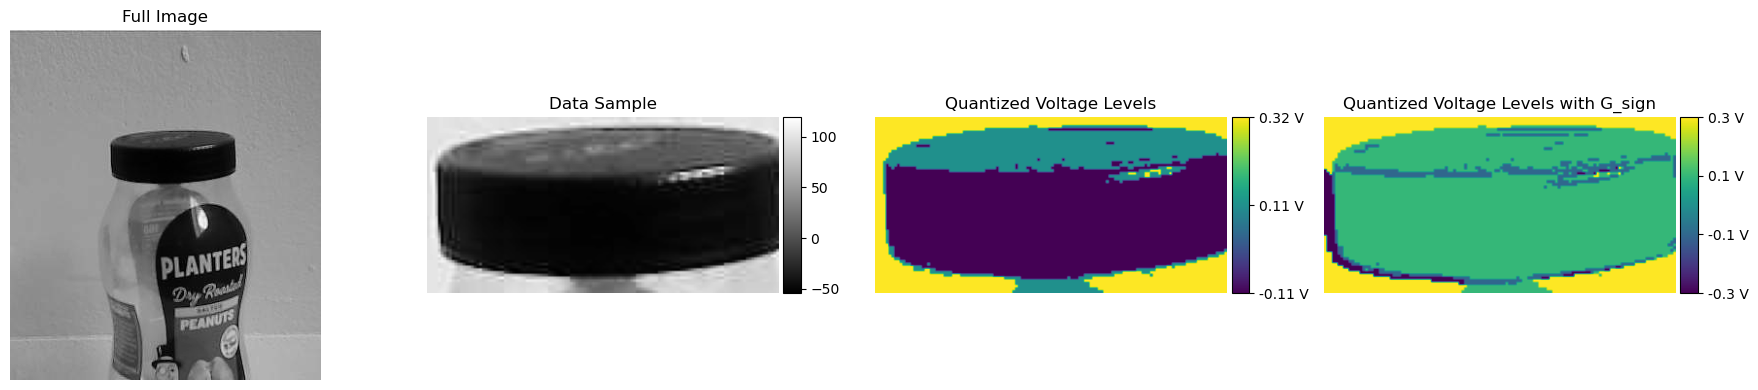

In [17]:
row_stride, col_stride = 20, 20

# Extract full image and patch
full_image = tm2.full_img_list[0]

ir, ic = 5, 5  # indices for patch position
Data_sample = full_image[
    ir * row_stride : ir * row_stride + tm2.temp_row,
    ic * col_stride : ic * col_stride + tm2.temp_col
]

noise_level = 0.0

# Quantization
sma, quantized_V_values = Data2Voltage(Data_sample.reshape(-1,), num_levels=8)
# quantized_V_values = add_gaussian_noise(quantized_V_values,noise_level)
quantized_V_values = quantized_V_values.reshape(Data_sample.shape)

# --- Plot setup ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# --- (1) Full Image ---
im0 = axes[0].imshow(full_image, cmap="gray")
axes[0].set_title("Full Image")
axes[0].axis("off")

# --- (2) Extracted Sample ---
im1 = axes[1].imshow((Data_sample-np.mean(Data_sample)), cmap="gray")
axes[1].set_title("Data Sample")
axes[1].axis("off")

# Colorbar for sample
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im1, cax=cax1)

# --- (3) Quantized Voltage Map ---
im2 = axes[2].imshow(quantized_V_values, cmap="viridis")
axes[2].set_title("Quantized Voltage Levels")
axes[2].axis("off")
# Colorbar for quantized voltage
divider2 = make_axes_locatable(axes[2])
cax2 = divider2.append_axes("right", size="5%", pad=0.05)
cb2 = plt.colorbar(im2, cax=cax2)

# Optional: show voltage levels as tick labels
unique_levels = np.unique(quantized_V_values)
cb2.set_ticks(unique_levels)
cb2.set_ticklabels([f"{v:.2f} V" for v in unique_levels])

# --- (3) Quantized Voltage Map ---
quantized_V_values_g = quantized_V_values * sign_map
quantized_V_values_g = np.round(quantized_V_values_g, 1)

im3 = axes[3].imshow(quantized_V_values_g, cmap="viridis")
axes[3].set_title("Quantized Voltage Levels with G_sign")
axes[3].axis("off")
# Colorbar for quantized voltage
divider3 = make_axes_locatable(axes[3])
cax3 = divider3.append_axes("right", size="5%", pad=0.05)
cb3 = plt.colorbar(im3, cax=cax3)

# Optional: show voltage levels as tick labels
unique_levels = np.unique(quantized_V_values_g)
cb3.set_ticks(unique_levels)
cb3.set_ticklabels([f"{v:.1f} V" for v in unique_levels])

plt.tight_layout()
plt.show()

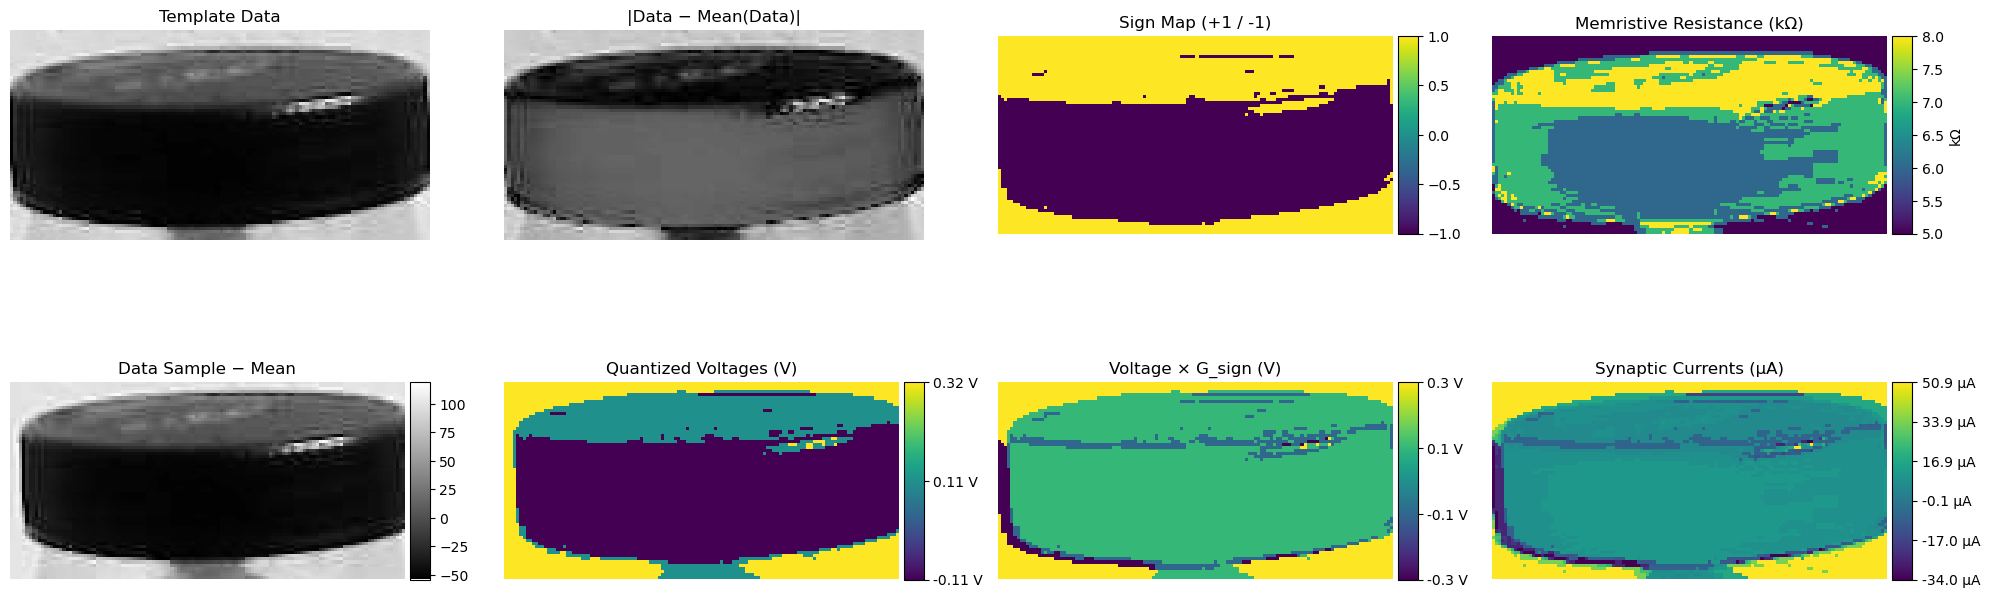

Total current sum: 117.586 mA


In [18]:
# =====================================
# 4. Compute Synaptic Currents
# =====================================
nr, nc = quantized_V_values_g.shape
I_syn_individual = np.zeros((nr, nc))

for i in range(nr):
    for j in range(nc):
        v = quantized_V_values_g[i, j]
        r = int(temp_R[i, j]) * 1000  # to ohms
        I_syn_individual[i, j] = -data_struct[v][r] * 1e6  # μA

# =====================================
# 5. Plot Setup (7 Subplots)
# =====================================
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

# (1) Template (temp_data)
im0 = axes[0].imshow(temp_data, cmap="gray")
axes[0].set_title("Template Data")
axes[0].axis("off")

# (2) |Data − Mean(Data)|
im1 = axes[1].imshow(np.abs(y), cmap="gray")
axes[1].set_title("|Data − Mean(Data)|")
axes[1].axis("off")

# (3) Sign Map
im2 = axes[2].imshow(sign_map, cmap="viridis", vmin=-1, vmax=1)
axes[2].set_title("Sign Map (+1 / -1)")
axes[2].axis("off")
divider2 = make_axes_locatable(axes[2])
cax2 = divider2.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im2, cax=cax2)

# (4) Resistance Map
im3 = axes[3].imshow(temp_R, cmap="viridis")
axes[3].set_title("Memristive Resistance (kΩ)")
axes[3].axis("off")
divider3 = make_axes_locatable(axes[3])
cax3 = divider3.append_axes("right", size="5%", pad=0.05)
cb3 = plt.colorbar(im3, cax=cax3)
cb3.set_label("kΩ")

# (5) Data Sample − Mean
im4 = axes[4].imshow(Data_sample - np.mean(Data_sample), cmap="gray")
axes[4].set_title("Data Sample − Mean")
axes[4].axis("off")
divider4 = make_axes_locatable(axes[4])
cax4 = divider4.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im4, cax=cax4)

# (6) Quantized Voltages
im5 = axes[5].imshow(quantized_V_values, cmap="viridis")
axes[5].set_title("Quantized Voltages (V)")
axes[5].axis("off")
divider5 = make_axes_locatable(axes[5])
cax5 = divider5.append_axes("right", size="5%", pad=0.05)
cb5 = plt.colorbar(im5, cax=cax5)
cb5.set_ticks(np.unique(quantized_V_values))
cb5.set_ticklabels([f"{v:.2f} V" for v in np.unique(quantized_V_values)])

# (7) Voltage × G_sign
im6 = axes[6].imshow(quantized_V_values_g, cmap="viridis")
axes[6].set_title("Voltage × G_sign (V)")
axes[6].axis("off")
divider6 = make_axes_locatable(axes[6])
cax6 = divider6.append_axes("right", size="5%", pad=0.05)
cb6 = plt.colorbar(im6, cax=cax6)
cb6.set_ticks(np.unique(quantized_V_values_g))
cb6.set_ticklabels([f"{v:.1f} V" for v in np.unique(quantized_V_values_g)])

# (8) Synaptic Currents
im7 = axes[7].imshow(I_syn_individual, cmap="viridis")
axes[7].set_title("Synaptic Currents (μA)")
axes[7].axis("off")
divider7 = make_axes_locatable(axes[7])
cax7 = divider7.append_axes("right", size="5%", pad=0.05)
cb7 = plt.colorbar(im7, cax=cax7)
tick_positions = np.linspace(I_syn_individual.min(), I_syn_individual.max(), 6)
cb7.set_ticks(tick_positions)
cb7.set_ticklabels([f"{i:.1f} μA" for i in tick_positions])

plt.tight_layout()
plt.show()

# =====================================
# 6. Total Current Sum
# =====================================
print(f"Total current sum: {np.sum(I_syn_individual) * 1e-3:.3f} mA")

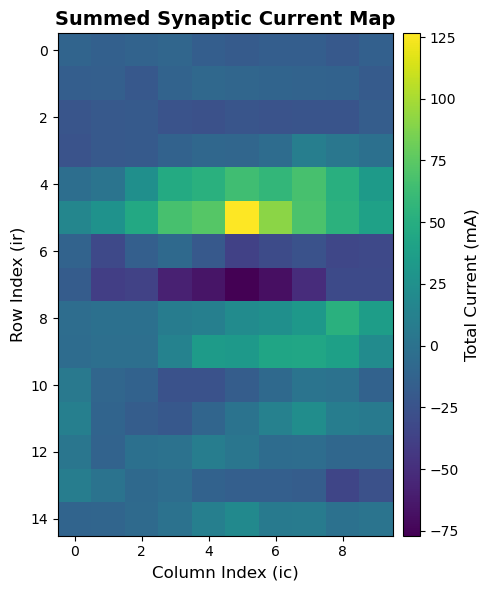

Max Current Sum: 126.50 mA
Min Current Sum: -76.96 mA
Mean Current Sum: -1.14 mA


In [22]:
# =============================
# 1. Setup
# =============================
full_image = tm2.full_img_list[0]
rows, cols = full_image.shape

# Get patch dimensions and stride
patch_r, patch_c = tm2.temp_row, tm2.temp_col

# Determine number of valid patch positions
n_r = (rows - patch_r) // col_stride + 1
n_c = (cols - patch_c) // col_stride + 1

# Initialize 2D array to store total currents
current_sum_map = np.zeros((n_r, n_c))

# =============================
# 2. Iterate through patch positions
# =============================
for ir in range(n_r):
    for ic in range(n_c):
        # Extract patch
        Data_sample = full_image[
            ir * col_stride : ir * col_stride + patch_r,
            ic * col_stride : ic * col_stride + patch_c
        ]

        # Quantize to voltage levels
        sma, quantized_V_values = Data2Voltage(Data_sample.reshape(-1,), num_levels=8)
        quantized_V_values = quantized_V_values.reshape(Data_sample.shape)
        # Apply sign map and round
        quantized_V_values_g = np.round(quantized_V_values * sign_map, 1)

        # Compute individual synaptic currents
        I_syn_individual = np.zeros_like(quantized_V_values_g)
        for i in range(patch_r):
            for j in range(patch_c):
                voltage = quantized_V_values_g[i, j]
                resistance = int(temp_R[i, j]) * 1000  # to ohms
                current_val = -data_struct[voltage][resistance] * 1e3 # µA
                noise = np.random.normal(0, 2.0 * abs(current_val))
                I_syn_individual[i, j] = current_val + noise

        # Store the sum of all currents (in µA)
        current_sum_map[ir, ic] = np.sum(I_syn_individual)

# =============================
# 3. Visualization
# =============================
fig, ax = plt.subplots(figsize=(7, 6))

# Show the summed current map
im = ax.imshow(current_sum_map, cmap="viridis", interpolation="nearest")
ax.set_title("Summed Synaptic Current Map", fontsize=14, fontweight="bold")
ax.set_xlabel("Column Index (ic)", fontsize=12)
ax.set_ylabel("Row Index (ir)", fontsize=12)

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Total Current (mA)", fontsize=12)

# Clean layout
plt.tight_layout()
plt.show()

# =============================
# 4. Summary
# =============================
print(f"Max Current Sum: {np.max(current_sum_map):.2f} mA")
print(f"Min Current Sum: {np.min(current_sum_map):.2f} mA")
print(f"Mean Current Sum: {np.mean(current_sum_map):.2f} mA")

In [30]:
import pandas as pd
import itertools

# === Define your lists ===
resistances = [3, 8, 13, 18]     # example resistance values (Ω)
voltages = [-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4]            # example voltage values (V)

# === Create all combinations (Resistance × Voltage) ===
combinations = list(itertools.product(resistances, voltages))

# === Create DataFrame ===
df = pd.DataFrame(combinations, columns=['Resistance (kohm)', 'Voltage (V)'])

# Add empty Current column
df['Current'] = ''

# === Save to Excel ===
output_file = "resistance_voltage_current.csv"
df.to_csv(output_file, index=False)

print(f"✅ File saved as: {output_file}")

✅ File saved as: resistance_voltage_current.csv
